In [15]:
# ==========================================
# 1. IMPORTAR BIBLIOTECAS
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

!pip install xgboost

sns.set(style="whitegrid")

# ==========================================
# 2. IMPORTAR BASE TRATADA
# ==========================================

df = pd.read_excel("base_tratada.xlsx")

print("Dimensão da base:")
print(df.shape)

print("\nColunas:")
print(df.columns)

df.head()

# ==========================================
# 3. CRIAR VARIÁVEIS AUXILIARES
# ==========================================

# Média geral das notas
df["media_notas"] = df[["portug","matem","inglês"]].mean(axis=1)

# Engajamento geral
df["engajamento_geral"] = df[["ieg","iaa","ips"]].mean(axis=1)

# Score pedagógico
df["score_pedagogico"] = df[["ida","ipp","ipv"]].mean(axis=1)





Dimensão da base:
(2845, 35)

Colunas:
Index(['ra', 'fase', 'turma', 'nome', 'idade_22', 'gênero', 'ano_pede',
       'pedra', 'inde', 'iaa', 'ieg', 'ips', 'ipp', 'ida', 'matem', 'portug',
       'inglês', 'ipv', 'ian', 'fase_ideal', 'defas', 'genero_bin',
       'pedra_num', 'fase_num', 'fase_ideal_num', 'tem_ingles', 'tem_ipp',
       'media_notas', 'engajamento_geral', 'score_pedagogico', 'gap_fase',
       'risco_defasagem', 'categoria_defasagem', 'nivel_defasagem',
       'dif_percepcao'],
      dtype='object')


nivel_defasagem  Severa  Adequada
ano_pede                         
2022                601       259
2023                544       387
2024                534       520


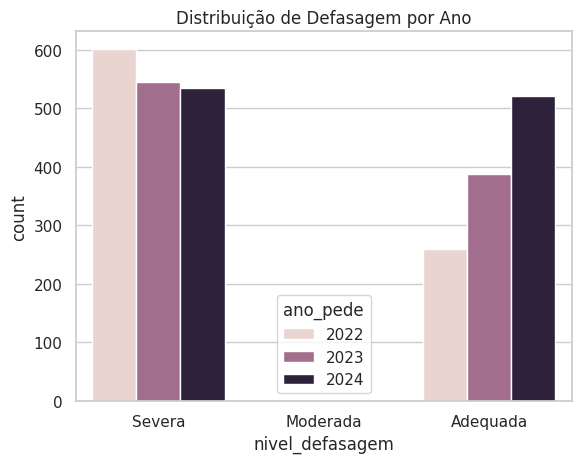

In [16]:
#1 Adequação do nível (IAN): Qual é o perfil geral de defasagem dos alunos (IAN) e como ele evolui ao longo do ano?

df["nivel_defasagem"] = pd.cut(
    df["ian"],
    bins=[0,5,7,10],
    labels=["Severa","Moderada","Adequada"]
)

tabela_ian = pd.crosstab(df["ano_pede"], df["nivel_defasagem"])

print(tabela_ian)

import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x="nivel_defasagem", hue="ano_pede")

plt.title("Distribuição de Defasagem por Ano")
plt.show()

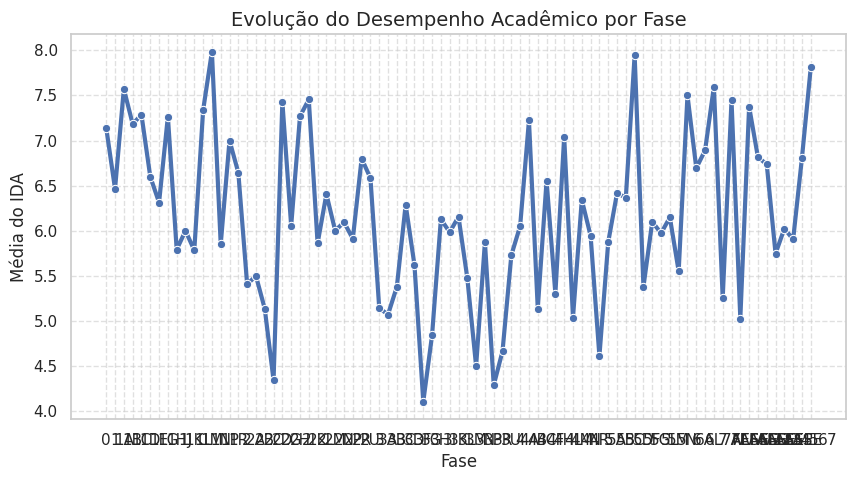

In [17]:
#2 Desempenho acadêmico (IDA): O desempenho acadêmico médio (IDA) está melhorando, estagnado ou caindo ao longo das fases e anos?

ida_fase = df.groupby("fase")["ida"].mean().reset_index()

plt.figure(figsize=(10,5))

sns.lineplot(
    data=ida_fase,
    x="fase",
    y="ida",
    marker="o",
    linewidth=3
)

plt.title("Evolução do Desempenho Acadêmico por Fase", fontsize=14)
plt.xlabel("Fase")
plt.ylabel("Média do IDA")

plt.grid(True, linestyle="--", alpha=0.6)

plt.show()

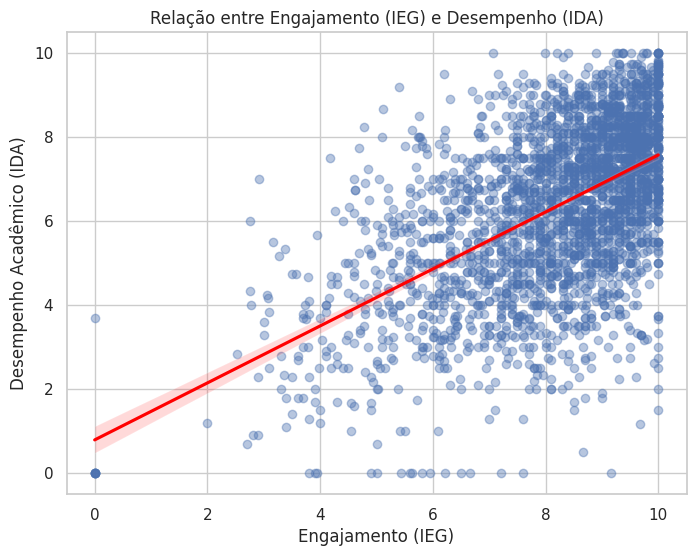

In [18]:
#3 Engajamento nas atividades (IEG): O grau de engajamento dos alunos (IEG) tem relação direta com seus indicadores de
#desempenho (IDA) e do ponto de virada (IPV)?

plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x="ieg",
    y="ida",
    scatter_kws={"alpha":0.4},
    line_kws={"color":"red"}
)

plt.title("Relação entre Engajamento (IEG) e Desempenho (IDA)")
plt.xlabel("Engajamento (IEG)")
plt.ylabel("Desempenho Acadêmico (IDA)")

plt.show()

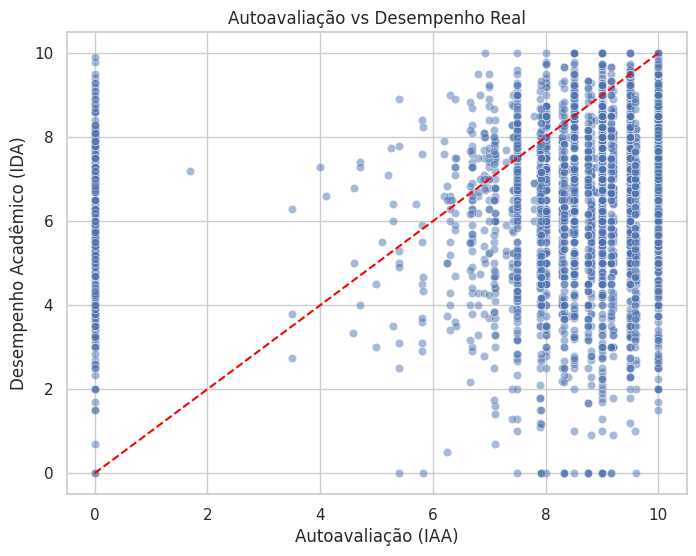

In [19]:
#4 Autoavaliação (IAA): As percepções dos alunos sobre si mesmos (IAA) são coerentes com seu desempenho real
#(IDA) e engajamento (IEG)?

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="iaa",
    y="ida",
    alpha=0.5
)

plt.plot([0,10],[0,10], color="red", linestyle="--")

plt.title("Autoavaliação vs Desempenho Real")
plt.xlabel("Autoavaliação (IAA)")
plt.ylabel("Desempenho Acadêmico (IDA)")

plt.show()

,ips,ida,ieg
ips,1.000000,0.022485,-0.047272
ida,0.022485,1.000000,0.543550
ieg,-0.047272,0.543550,1.000000


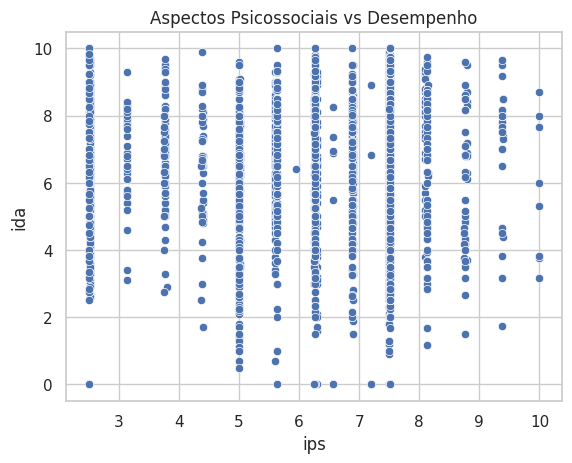

In [20]:
#5 Aspectos psicossociais (IPS): Há padrões psicossociais (IPS) que antecedem quedas de desempenho acadêmico ou de engajamento?

sns.scatterplot(
    data=df,
    x="ips",
    y="ida"
)

plt.title("Aspectos Psicossociais vs Desempenho")

df[["ips","ida","ieg"]].corr()

Text(0.5, 1.0, 'IPP por Nível de Defasagem')

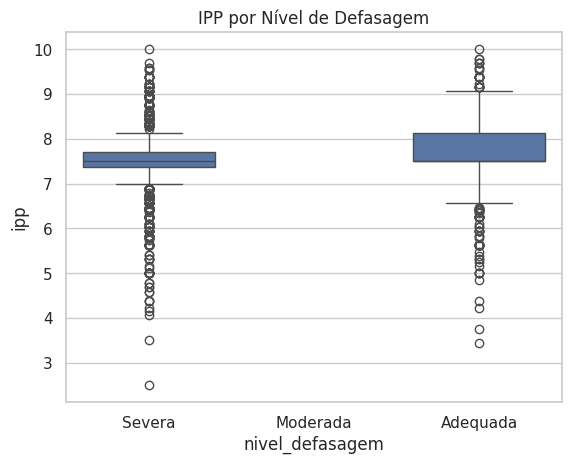

In [21]:
#6 Aspectos psicopedagógicos (IPP): As avaliações psicopedagógicas (IPP) confirmam ou contradizem a defasagem identificada pelo IAN?

sns.boxplot(
    data=df,
    x="nivel_defasagem",
    y="ipp"
)

plt.title("IPP por Nível de Defasagem")

<Axes: >

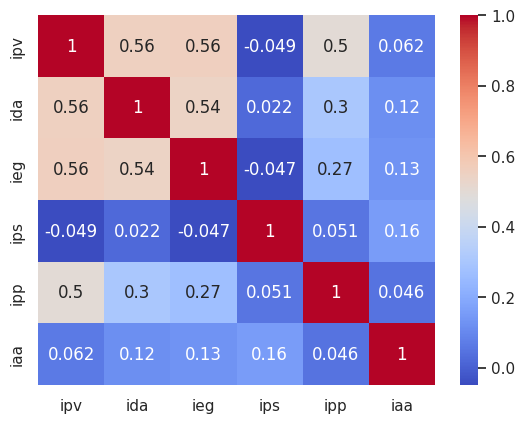

In [22]:
#7 Ponto de virada (IPV): Quais comportamentos - acadêmicos, emocionais ou de engajamento - mais influenciam o IPV ao longo do tempo?

df_corr_ipv = df[[
"ipv",
"ida",
"ieg",
"ips",
"ipp",
"iaa"
]].corr()

sns.heatmap(df_corr_ipv, annot=True, cmap="coolwarm")

<Axes: >

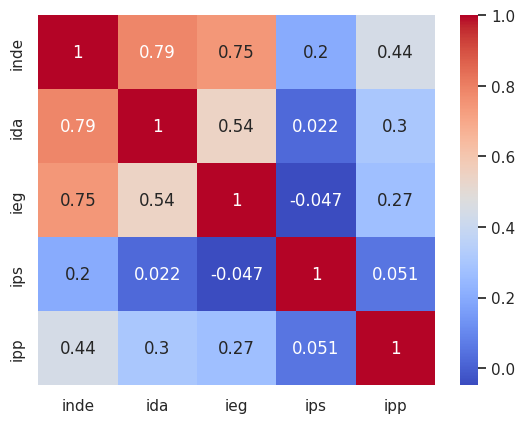

In [23]:
#8 Multidimensionalidade dos indicadores: Quais combinações de indicadores (IDA + IEG + IPS + IPP) elevam mais a nota global do aluno (INDE)?

df_corr_inde = df[[
"inde",
"ida",
"ieg",
"ips",
"ipp"
]].corr()

sns.heatmap(df_corr_inde, annot=True, cmap="coolwarm")



===== XGBoost =====

Accuracy: 0.8664323374340949
Precision: 0.8693181818181818
Recall: 0.9107142857142857
F1 Score: 0.8895348837209303
ROC AUC: 0.929235642754956

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.80      0.83       233
           1       0.87      0.91      0.89       336

    accuracy                           0.87       569
   macro avg       0.87      0.86      0.86       569
weighted avg       0.87      0.87      0.87       569



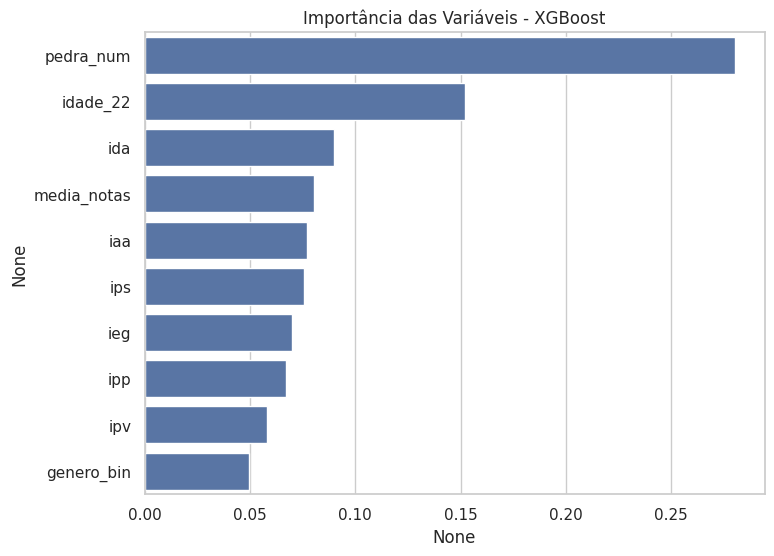

In [35]:
#9 Previsão de risco com Machine Learning: Quais padrões nos indicadores permitem identificar alunos em risco antes de queda no desempenho
#ou aumento da defasagem? Construa um modelo preditivo que mostre uma
#probabilidade do aluno ou aluna entrar em risco de defasagem.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

features = [

"idade_22",
"genero_bin",
"ieg",
"ida",
"iaa",
"ips",
"ipp",
"ipv",
"media_notas",
"pedra_num"

]

X = df[features]
y = df["risco_defasagem"]

def avaliar_modelo(nome_modelo, y_true, y_pred, y_prob):

    print(f"\n===== {nome_modelo} =====\n")

    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1 Score:", f1_score(y_true, y_pred))
    print("ROC AUC:", roc_auc_score(y_true, y_prob))

    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred))

    # Matriz de confusão
    cm = confusion_matrix(y_true, y_pred)



    xgb_model = XGBClassifier(

    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"

)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

avaliar_modelo(
    "XGBoost",
    y_test,
    y_pred_xgb,
    y_prob_xgb
)

importancias = pd.Series(
    xgb_model.feature_importances_,
    index=features
).sort_values(ascending=False)

plt.figure(figsize=(8,6))

sns.barplot(
    x=importancias,
    y=importancias.index
)

plt.title("Importância das Variáveis - XGBoost")

plt.show()

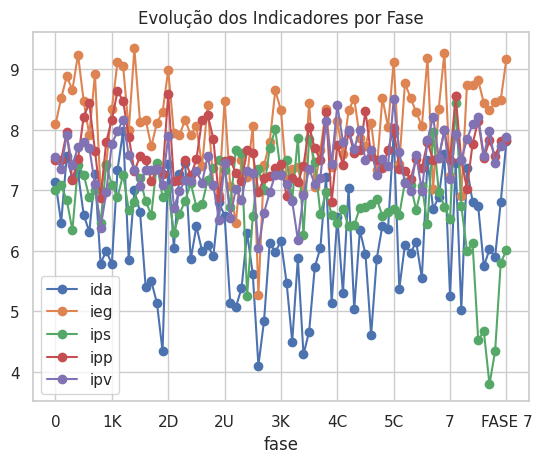

In [36]:
#10 Efetividade do programa: Os indicadores mostram melhora consistente ao longo do ciclo nas diferentes fases (Quartzo, Ágata, Ametista e
#Topázio), confirmando o impacto real do programa?

indicadores = ["ida","ieg","ips","ipp","ipv"]

df_fase = df.groupby("fase")[indicadores].mean()

df_fase.plot(kind="line", marker="o")

plt.title("Evolução dos Indicadores por Fase")
plt.show()

Text(0.5, 1.0, 'Risco de Defasagem por Nível PEDRA')

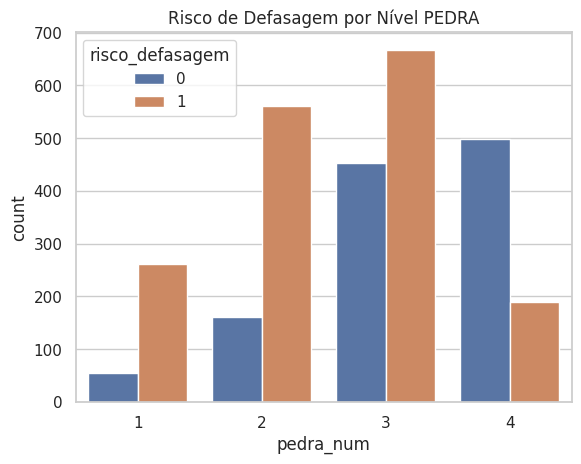

In [37]:
#11 Insights e criatividade: Você pode adicionar mais insights e pontos
#de vista não abordados nas perguntas, utilize a criatividade e a análise dos dados
#para trazer sugestões para a Passos Mágicos.

sns.countplot(
    data=df,
    x="pedra_num",
    hue="risco_defasagem"
)

plt.title("Risco de Defasagem por Nível PEDRA")